# GEOG5990M Final Assignment

(The cover sheet has been adapted from the word doc. to support use with .ipynb files - please complete all the requested info.)
###  COURSEWORK COVERSHEET
- Student ID number: 202021408
- Module code: GEOG5990M
- Module title: Programming for Geographical Information Analysis: Core Skills
- Assignment title: Spatial data science report
- Declared word count: 1404

#### Use of Generative Artificial Intelligence (Gen AI) in this assessment – delete one statement as appropriate
- I have made no use of Gen A



By submitting the work in this notebook you confirm your compliance with the University’s definition of Academic Integrity as: “a commitment to good study practices and shared values which ensures that my work is a true expression of my own understanding and ideas, giving credit to others where their work contributes to mine”. Double-check that your referencing and use of quotations is consistent with this commitment.

You also confirm that your declared word count accurately reflects the number of words in your submission, excluding the overall title, Gen AI use acknowledgement, bibliography/reference list, text/numbers in tables and figures (although table and figure captions are included in the word count).

# **Is there an association between building age and price in Leeds?**

In [90]:
#read in required packages

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [92]:
#warning

In [93]:
import warnings
warnings.filterwarnings('ignore')

In [94]:
#read age

In [95]:
age_data = pd.read_csv("APHS_EW_LSOA_2024.csv")

In [96]:
#see data

In [97]:
print("First 5 rows of the dataset:")
print(age_data.head())

print("\nDataset dimensions (rows, columns):")
print(age_data.shape)

print("\nColumn names:")
print(age_data.columns.tolist())

First 5 rows of the dataset:
    LSOA21CD                   LSOA21NM      LADCD                 LADNM  \
0  E01000001        City of London 001A  E09000001        City of London   
1  E01000002        City of London 001B  E09000001        City of London   
2  E01000003        City of London 001C  E09000001        City of London   
3  E01000005        City of London 001E  E09000001        City of London   
4  E01000006  Barking and Dagenham 016A  E09000002  Barking and Dagenham   

     BPMODAL  BPMODALP   BPMEDIAN  GINIINDEX  NATMEDCOMP  LADMEDCOMP  ...  \
0  1965-1972        80  1965-1972      94.54           1           0  ...   
1  1965-1972        61  1965-1972      92.49           1           0  ...   
2  1965-1972        76  1965-1972      95.06           1           0  ...   
3  2019-2021        22  1973-1982      69.96           2           1  ...   
4  1919-1929        31  1930-1939      79.96          -2           0  ...   

   BP196572P BP197382P BP198392P BP199399P BP200008

In [98]:
#D=leeds

In [99]:
leeds_age = age_data[age_data.iloc[:, 3] == "Leeds"]

In [100]:
#A=LSOA21CD G=BPMEDIAN

In [101]:
leeds_age_clean = leeds_age.iloc[:, [0, 6]]

In [102]:
#Missing

In [103]:
print("Missing values before cleaning:")
print(leeds_age_clean.isnull().sum())

Missing values before cleaning:
LSOA21CD    0
BPMEDIAN    0
dtype: int64


In [104]:
#no missing

In [105]:
#clean

In [106]:
leeds_age_clean = leeds_age_clean.dropna()

In [107]:
#rename

In [108]:
leeds_age_clean.columns = ["LSOA", "Median_Build_Age"]

In [109]:
#check

In [110]:
print("\nCleaned Leeds building age data:")
print(leeds_age_clean.head())
print("Final dataset shape:", leeds_age_clean.shape)


Cleaned Leeds building age data:
            LSOA Median_Build_Age
10719  E01011264        1945-1954
10720  E01011265        1955-1964
10721  E01011266        2000-2008
10722  E01011267        1955-1964
10723  E01011268        1955-1964
Final dataset shape: (488, 2)


In [111]:
#read price

In [112]:
price_data = pd.read_excel(
    "1a.xlsx",
    skiprows=5
)

In [113]:
print("First 5 rows of price data:")
print(price_data.head())

First 5 rows of price data:
  Local authority code Local authority name  LSOA code        LSOA name  \
0            E06000001           Hartlepool  E01011949  Hartlepool 009A   
1            E06000001           Hartlepool  E01011950  Hartlepool 008A   
2            E06000001           Hartlepool  E01011951  Hartlepool 007A   
3            E06000001           Hartlepool  E01011952  Hartlepool 002A   
4            E06000001           Hartlepool  E01011953  Hartlepool 002B   

  Year ending Dec 1995 Year ending Mar 1996 Year ending Jun 1996  \
0                34750                34500                30500   
1                25000                25000                25300   
2                27000                27000                27250   
3                44500                44500                30000   
4                22000                27000                27000   

  Year ending Sep 1996 Year ending Dec 1996 Year ending Mar 1997  ...  \
0                30000                2

In [114]:
#leeds

In [115]:
leeds_price = price_data[price_data.iloc[:, 1] == "Leeds"]

In [116]:
#A=Local authority code DJ=Year ending Mar 2023

In [117]:
leeds_price_clean = leeds_price.iloc[:, [2, 113]]

In [118]:
#clean

In [119]:
#：is empty

In [120]:
leeds_price_clean = leeds_price_clean.replace(":", pd.NA)

In [121]:
leeds_price_clean = leeds_price_clean.dropna()

In [122]:
#rename

In [123]:
leeds_price_clean.columns = ["LSOA", "Median_Price"]

In [124]:
#see see

In [125]:
print("\nMissing values in price data:")
print(leeds_price_clean.isnull().sum())
leeds_price_clean = leeds_price_clean.dropna()


Missing values in price data:
LSOA            0
Median_Price    0
dtype: int64


In [126]:
#MIN

In [127]:
print("Minimum Price:", leeds_price_clean["Median_Price"].min())

Minimum Price: 65000


In [128]:
#MAX

In [129]:
print("Maximum Price:", leeds_price_clean["Median_Price"].max())

Maximum Price: 854975


In [130]:
#MEDIAN

In [131]:
print("Median Price:", leeds_price_clean["Median_Price"].median())

Median Price: 220000.0


In [132]:
#Data Visualisation

In [133]:
#Merge

In [134]:
combined_data = pd.merge(leeds_age_clean, leeds_price_clean, on='LSOA', how='inner')

In [135]:
#check

In [136]:
print('Number of rows after merging:', combined_data.shape[0])

Number of rows after merging: 456


In [137]:
#missing

In [138]:
print('Missing values in combined data:')
print(combined_data.isnull().sum())

Missing values in combined data:
LSOA                0
Median_Build_Age    0
Median_Price        0
dtype: int64


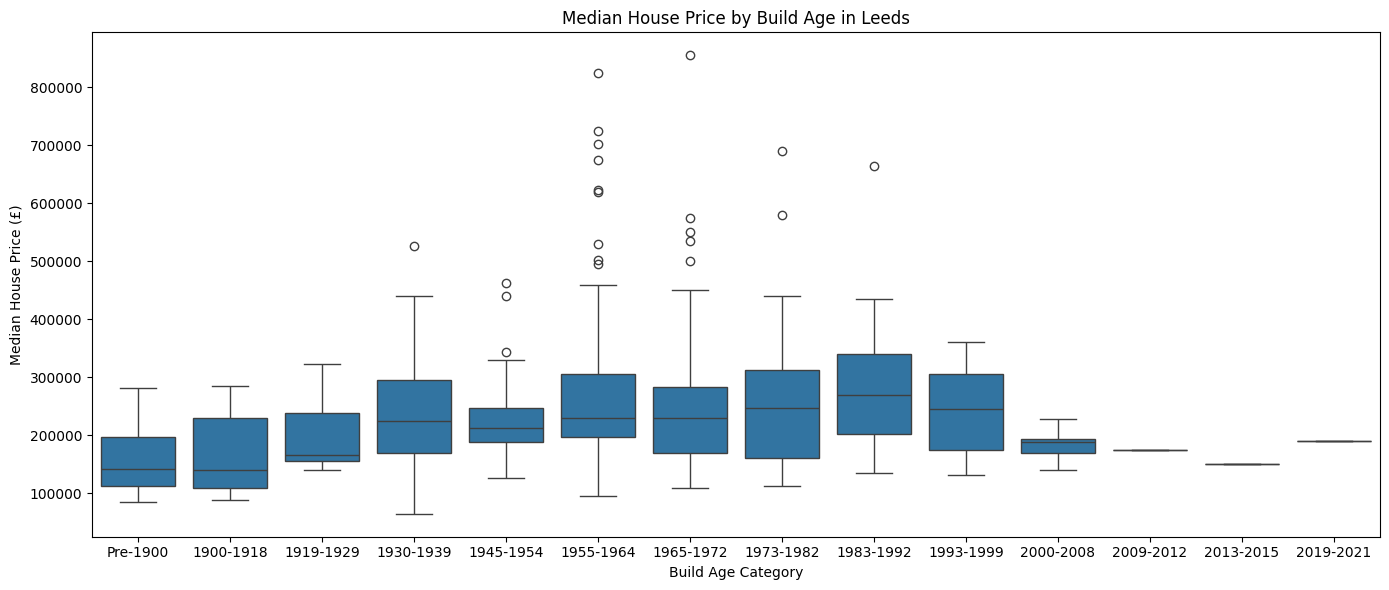

In [139]:
#draw
#year
desired_order = [
    "Pre-1900",
    "1900-1918",
    "1919-1929",
    "1930-1939",
    "1945-1954",
    "1955-1964",
    "1965-1972",
    "1973-1982",
    "1983-1992",
    "1993-1999",
    "2000-2008",
    "2009-2012",
    "2013-2015",
    "2019-2021"
]
#size
plt.figure(figsize=(14,6))
#X=house age Y=house price
sns.boxplot(x="Median_Build_Age", y="Median_Price", data=combined_data,
            order=desired_order)
#title X Y
plt.title("Median House Price by Build Age in Leeds")
plt.xlabel("Build Age Category")
plt.ylabel("Median House Price (£)")
#adjust
plt.tight_layout()
#show
plt.show()




In [140]:
#Grape2

In [141]:
#north arrow

In [142]:
!pip install git+https://github.com/pmdscully/geo_northarrow.git

  Cloning https://github.com/pmdscully/geo_northarrow.git to /tmp/pip-req-build-srwbh4kt
  Running command git clone --filter=blob:none --quiet https://github.com/pmdscully/geo_northarrow.git /tmp/pip-req-build-srwbh4kt
  Resolved https://github.com/pmdscully/geo_northarrow.git to commit c530ad3f9558d05355543e9fe7671f26cd0ffa02
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [143]:
#import

In [144]:
import geopandas as gpd
from geo_northarrow import add_north_arrow
import numpy as np

In [145]:
#geojson

In [146]:
leeds = gpd.read_file("Leeds.geojson")

In [147]:
#see see

In [148]:
print(leeds.head())

     FID   LSOA21CD    LSOA21NM   BNG_E   BNG_N     LONG       LAT  \
0  10720  E01011264  Leeds 011A  420937  441836 -1.68306  53.87232   
1  10721  E01011265  Leeds 009A  418988  441951 -1.71269  53.87343   
2  10722  E01011266  Leeds 008A  417489  442615 -1.73545  53.87945   
3  10723  E01011267  Leeds 009B  419641  442025 -1.70276  53.87407   
4  10724  E01011268  Leeds 010A  420224  441935 -1.69390  53.87324   

                               GlobalID  \
0  14a73329-fc8f-464c-a4fa-1963baa35500   
1  eda471dd-f408-4dab-917e-c5e188310b35   
2  286c32c5-ef49-4ecc-a45e-57630c165c62   
3  318cfaa3-9f08-4d61-a30e-82e903f3a7ba   
4  049e79f0-cd9e-47dc-848b-b6d6fa6825ac   

                                            geometry  
0  POLYGON ((421248.688 442315.812, 421284.072 44...  
1  POLYGON ((418635 442559, 418637.555 442552.869...  
2  POLYGON ((417783.688 443382.312, 417788.688 44...  
3  POLYGON ((419607.843 442388.568, 419612.752 44...  
4  POLYGON ((420442.406 442436.687, 420443.31

In [149]:
#LSOA=LSOA21CD

In [150]:
#LSOA21CD no empty

In [151]:
leeds_final = leeds.merge(combined_data, left_on="LSOA21CD", right_on="LSOA", how="left")

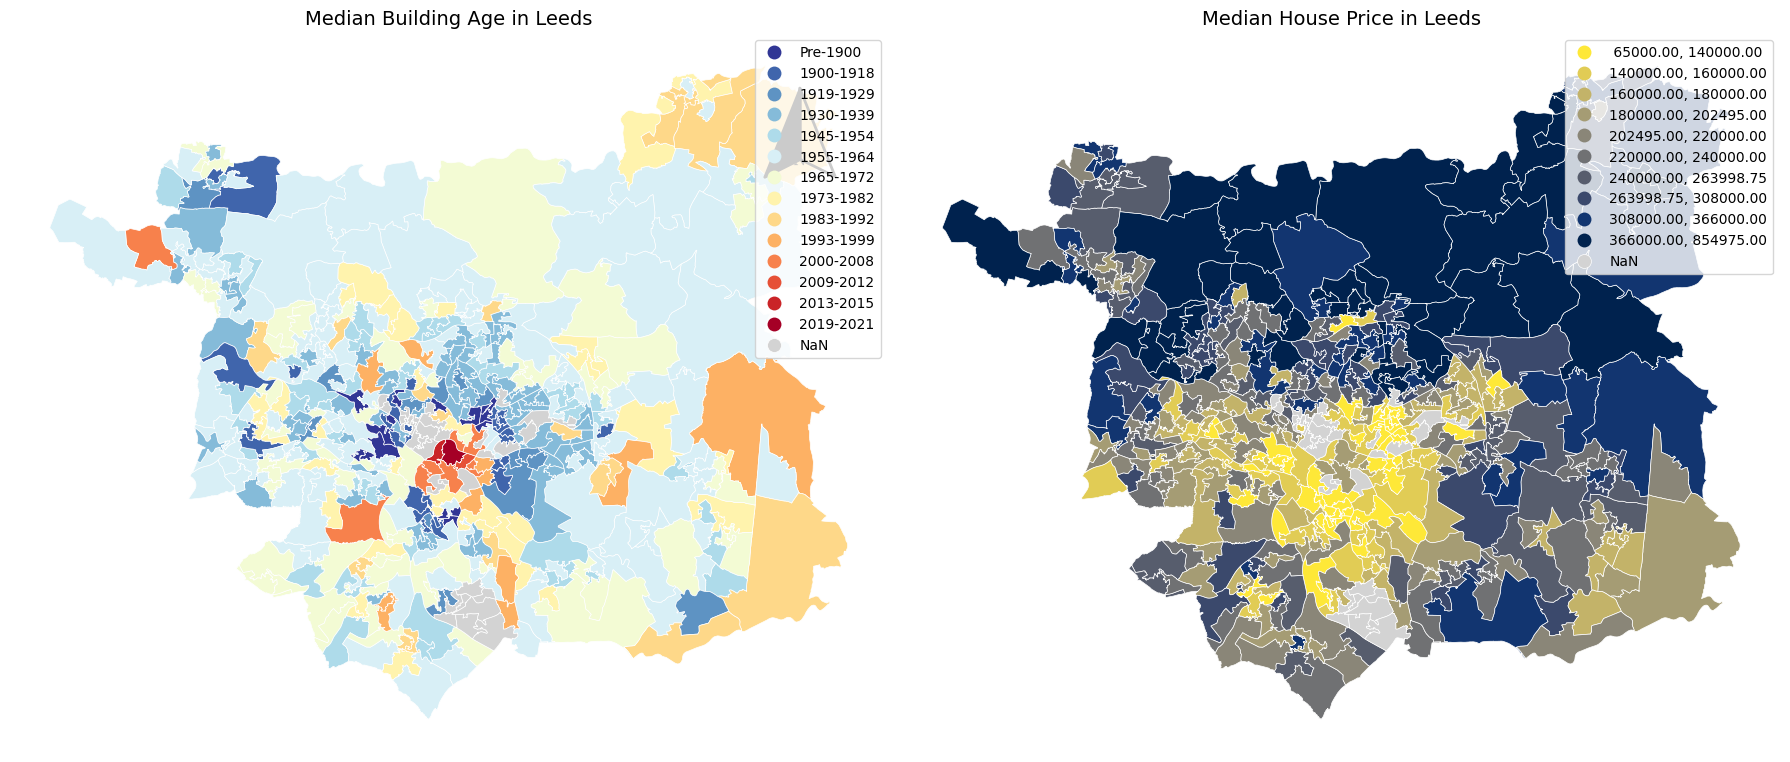

In [152]:
#two maps
#age order
age_order = [
    "Pre-1900",
    "1900-1918",
    "1919-1929",
    "1930-1939",
    "1945-1954",
    "1955-1964",
    "1965-1972",
    "1973-1982",
    "1983-1992",
    "1993-1999",
    "2000-2008",
    "2009-2012",
    "2013-2015",
    "2019-2021"
]
leeds_final["Median_Build_Age"] = pd.Categorical(
    leeds_final["Median_Build_Age"],
    categories=age_order,
    ordered=True
)
#draw
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
#left
#age
leeds_final.plot(
    ax=ax1,
    column="Median_Build_Age",

   legend=True,

    edgecolor="white",
    linewidth=0.5,
    cmap="RdYlBu_r",
    missing_kwds={"color": "lightgrey"}
    )
#title
ax1.set_title("Median Building Age in Leeds", fontsize=14)
#axis off
ax1.set_axis_off()
#north arrow
add_north_arrow(ax1)
#right
#price
leeds_final.plot(
    ax=ax2,
    column="Median_Price",
    scheme="quantiles",
    k=10,
    legend=True,
    edgecolor="white",
    linewidth=0.5,
    cmap="cividis_r",
    missing_kwds={"color": "lightgrey"},
)
#title
ax2.set_title("Median House Price in Leeds", fontsize=14)
#axis off
ax2.set_axis_off()
#adjust
plt.tight_layout()
#show
plt.show()

# **Is there an association between building age and price in Leeds?**


Introduce


The relationship between housing prices and the age of the housing has significant implications for urban planning, residents' affordability, and residents' quality of life. The research question of this report is: Is there an association between building age and price in Leeds? The study area is the city of Leeds, which has houses built from 1900 to the present. The report is based on the Lower Layer Super Output Area (LSOA) scale and uses the median house price and median house age of the LSOA. The audience of this report are policy makers, ordinary people who wish to purchase houses, and real estate practitioners.

Data Sources


The data in the report comes from two sources: one is a map, and another is an image of a north arrow and some Python packages.


The housing prices are from the UK National Statistics, released on September 23, 2023, based on the lower layer super output area (LSOA) division of England and Wales [1]. Unlike other regions that calculate prices per square meter, the UK Statistics Bureau uses the overall housing price statistics. The average value of a region's houses is difficult to represent the housing price level of that region because the size, age, and decoration of houses vary. Therefore, the median value is chosen to represent the housing prices. Some LSOAs have prices marked as ":", which were not included in the statistics.


The age of the houses is from the website www.datadaptive.com "Age Profiles of Housing Stock in England and Wales", whose data source is the Valuation Office Agency [2]. This data can be used for free. The data has the median "BPMEDIAN" divided by LSOA to avoid being affected by extreme values and maximum values. The median can represent the mainstream housing year of the region. It is divided into 16 different years from 1900 to 2021.


The map source is Leeds.geojson used in the course, which was extracted from the boundary of Leeds city in December 2021 by the UK National Statistics [3]. All maps are too large, so only the map of the research area is used.

Data Cleaning

Upload the data. The "HPSSA Dataset 46 - Median price paid for residential properties by LSOA" file is too large. Save sheet 1a as the data.

The housing year data is for the entire UK, so only the row with the name "Leeds" is retained, which is the fourth column, D column "LADNM". Also, the rows where the A column "LSOA21CD" and G column "BPMEDIAN" match "Leeds" are to be retained. In Python, the A column is 0 and the G column is 6. Rename. The data has 488 rows.

The housing prices are in multiple tables. In the 1a table, only the rows where the column "Local authority name" is "Leeds" are retained. Then, the columns "C column LSOA code" and "DJ column Year ending Mar 2023" are retained, representing the prices as of March 2023. The C column is 2 and the DJ column is 113. There are empty columns in the housing prices. Replace ":" with pd.NA and then delete the rows with empty values. Rename. The minimum price of a house is £65,000, the maximum is £854,975, and the median is £220,000 per house.

Combine the data. The LSOA is the same and both tables have it, so they are connected. It is found that there are only 456 rows now.

Methodology

Two graphs were made. The first one is a box plot with age on the X-axis and price on the Y-axis. The second graph is two maps of Leeds colored according to the age of the houses and the price of the houses.

Box plot

The years are defined in chronological order. The X-axis is "Median_Build_Age" and the Y-axis is "Median_Price". Add the title, X-axis, Y-axis, adjust and display. A scatter plot can be made, but since the house age is a time period, a box plot was chosen.

Map

Download the compass, add the package, and include "Leeds.geojson", which is the map of Leeds. There is a column named "LSOA21CD" in the map, which exists on the map. Whether there is data for house prices or house age, all rows should be based on the map. If there is no data, it should be displayed in gray. One map cannot clearly represent the data, so two maps are produced simultaneously.

Age Map

Tell the computer the correct order and confirm it again. The left map colors the houses based on their age, considering the color-blind group, using the "RdYlBu_r" red-yellow-blue reverse gradient. The areas without data are marked in light gray.

House Price Map

Sort the house prices from low to high, divide them into 10 groups, with approximately the same number in each group, color them based on the price, using the "cividis_r" color gradient in the yellow-blue direction. Areas without data are marked as "lightgrey".

Result

From the box plot, it can be seen that the relationship between the age of the house and the house price is not that the newer the house, the higher the price. The average price of houses built before 1900 was the lowest, and the prices of houses built after 2000 were also relatively low. The prices of houses built from 1930 to 1999 were not low. There were many very high points for houses built from 1955 to 1972, which were some very luxurious mansions at that time. In the area in the southwest of the city center, there is a large area of very new houses.

 Other houses built in the recent decades are located in the northwest and southwest edges of the city of Leeds, and there are also several areas in the eastern part of the city with new houses built after 2000. In addition, a large area of the northwest suburbs and the northern suburbs are all connected with newly built houses from 1955 to 1972. There are areas in the city center and the western part adjacent to the city center with very old houses, which can be traced back to before 1900.

The distribution of house prices is different from the age of the houses. The prices of houses of the same color are connected together and follow a gradient pattern. The closer to the city center, the lower the price, and the closer to the suburbs, the higher the price. The prices in the southern suburbs of Leeds are medium, while those in the northern suburbs are high. The price of a house in the city center does not exceed 150,000 pounds, and the price of a house in the northern suburbs is not less than 300,000 pounds.

Discussion

From the graph, it can be seen that the price of houses is greatly influenced by their location. Houses in the city center are cheaper, while those in the suburbs are more expensive. Older houses in the city center consume more energy. To stay warm in winter, one would have to spend more on fuel than those living in new houses. There are also issues specific to old houses such as aging water pipes. And here, there are poor people living. The city government should actively update the facilities of old houses and provide economic assistance to families living in energy-consuming old houses before the updates are made.

For ordinary people, especially young and poor individuals, it is best to choose newly built houses in the city center. Fortunately, the relationship between house prices and their age is not strong, which gives young people without cars, those who rely on public transportation or walk a good starting point. They can live in the city center, pursue their studies or develop their careers. Those who want to buy a good house can choose to purchase in the northern suburbs. The houses there were built from 1955 to 1972. These houses are connected in a block and there are also extremely expensive mansions in the middle. Real estate professionals can recommend houses based on the needs of the clients.

Conclusion

The relationship between the construction year of a house and its price is not a simple linear one. The price of a house is more closely related to its geographical location. This study provides support for the public to understand urban house prices and offers reference for policymakers.

This is an example block of markdown text I want to reference <a href="#ref1">[1]</a>. I might need to add some more citations <a href="#ref2">[2]</a><a href="#ref2">[3]</a>

## References

<p><a href="https://www.ons.gov.uk/peoplepopulationandcommunity/housing/datasets/medianpricepaidbylowerlayersuperoutputareahpssadataset46">[1]</a> Office for National Statistics.Median house prices by lower layer super output area: HPSSA dataset 46. [online]. 2023. [Accessed:30 April 2026]. Available from: https://www.ons.gov.uk/peoplepopulationandcommunity/housing/datasets/medianpricepaidbylowerlayersuperoutputareahpssadataset46
<p><a href="https://datadaptive.com">[2]</a> Data Adaptive. Age Profiles of Housing Stock in England and Wales. italicized textitalicized text. [online] .2024.[Accessed:30 April 2026]. Available from: https://datadaptive.com </p>

<p><a href="https://github.com/FrancescaPontin/GEOG5990M">[3]</a> GEOG5990M course materials. [online]. [Accessed:30 April 2026] .Available from: https://github.com/FrancescaPontin/GEOG5990M</p>

Data Visualisation
- Don't forget to present your final two data visualisation (one spatial and one non-spatial) and the justifications about the decisions you made whilst preparing and visualising the data.

In [153]:
#non-spatial

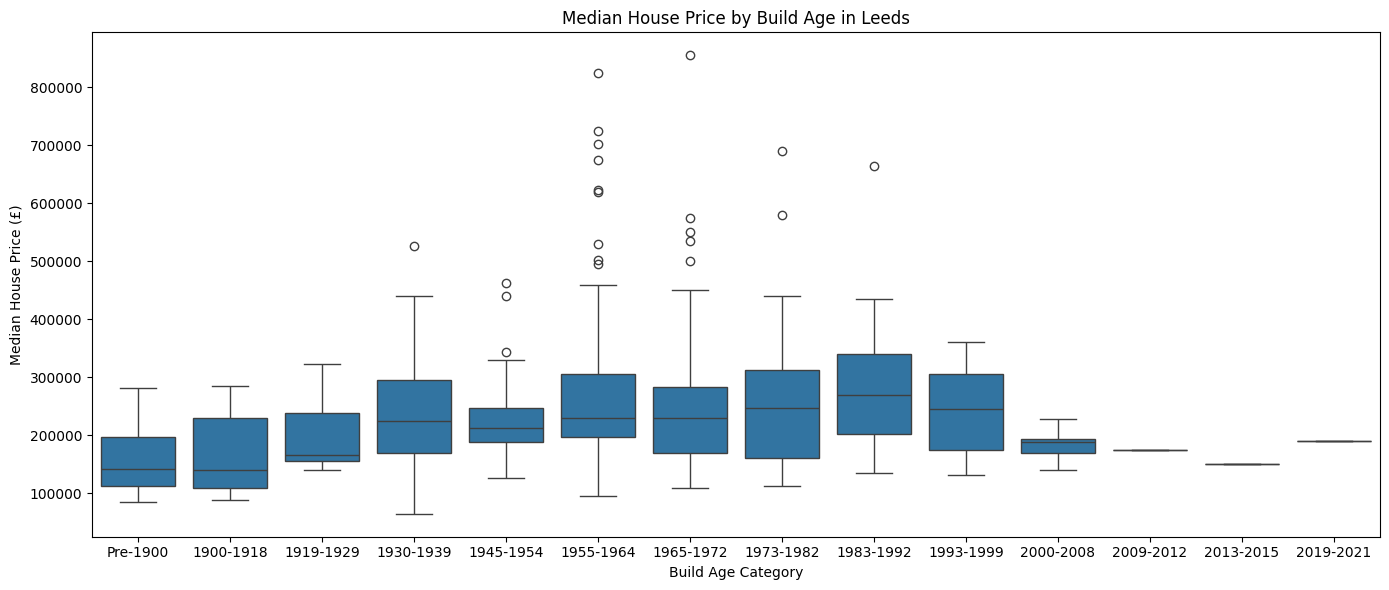

In [154]:
#spatial

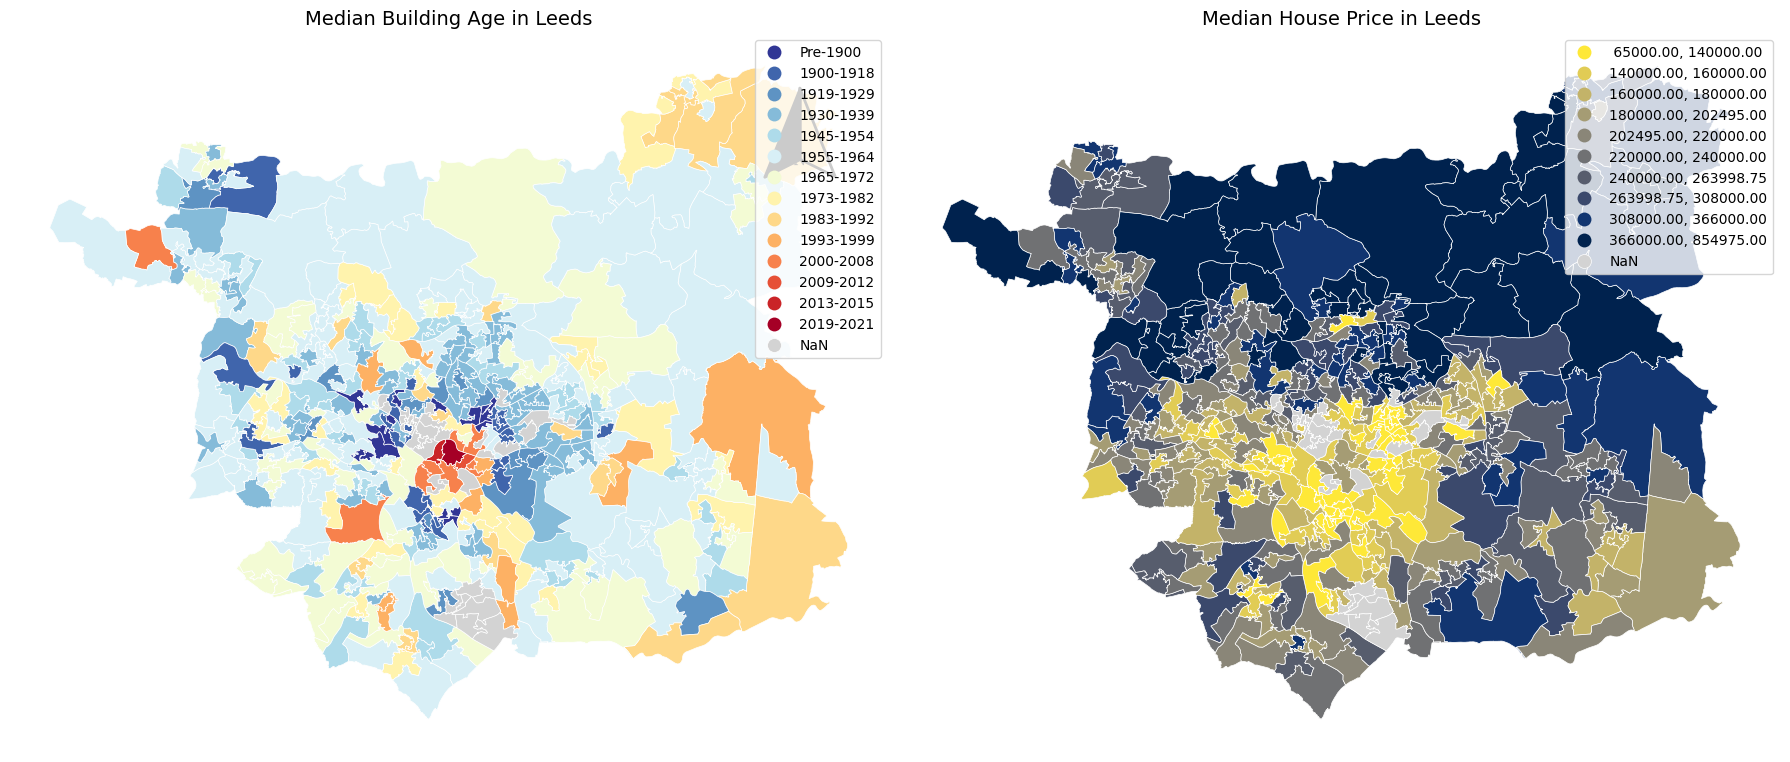